# Experiment: Phase B Offline Benchmark

Mục tiêu:
- Benchmark checkpoint champion của `Pha B` trên **toàn bộ test set** với cùng logic metric đã dùng trong pipeline `FT1/Report1`.
- Chạy được cả local và Colab.
- Nếu là Colab thì chỉ stage `data/process/test` về disk local của runtime để giảm nghẽn I/O.

Outputs:
- `evaluation/phase_b_offline_benchmark/outputs/<benchmark_name>/reports`
- `evaluation/phase_b_offline_benchmark/outputs/<benchmark_name>/plots`

Chính sách metric:
- `core`: metric full-test đủ mạnh để quyết định offline quality
- `secondary`: metric oracle subset để continuity với các suite cũ
- `diagnostic`: metric hữu ích để đọc failure mode nhưng không nên dùng làm gate chính


In [5]:
import os
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)


In [6]:
import json
import os
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, display


def env_bool(name: str, default: bool) -> bool:
    raw = os.environ.get(name, '').strip().lower()
    if not raw:
        return bool(default)
    return raw in {'1', 'true', 'yes', 'y'}


def env_int(name: str, default: int) -> int:
    raw = os.environ.get(name, '').strip()
    return int(raw) if raw else int(default)


def env_optional_int(name: str):
    raw = os.environ.get(name, '').strip()
    return int(raw) if raw else None


def env_optional_float(name: str):
    raw = os.environ.get(name, '').strip()
    return float(raw) if raw else None


def find_repo_root(start: Path) -> Path:
    markers = (
        ('model',),
        ('train_v2_TF1', 'ft1_colab_helpers.py'),
        ('train_v5_phaseB', 'phase_b_train_helpers.py'),
        ('evaluation', 'phase_b_offline_benchmark', 'offline_benchmark_helpers.py'),
    )
    for candidate in [start.resolve(), *start.resolve().parents]:
        if all(candidate.joinpath(*parts).exists() for parts in markers):
            return candidate
    raise RuntimeError(f'Cannot resolve repo root from {start}')


def resolve_colab_repo_root() -> Path:
    env_root = os.environ.get('CHESS_REPO_ROOT', '').strip()
    if env_root:
        candidate = Path(env_root)
        if candidate.exists():
            return candidate.resolve()
    candidates = [Path('/content/drive/MyDrive/chess_engine')]
    shortcut_root = Path('/content/drive/.shortcut-targets-by-id')
    if shortcut_root.exists():
        candidates.extend(shortcut_root.glob('*/chess_engine'))
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Cannot locate repo root in Colab. Set CHESS_REPO_ROOT explicitly.')


RUN_NAME = os.environ.get('CHESS_BENCHMARK_RUN_NAME', 'dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1').strip()
CHECKPOINT_POLICY = os.environ.get('CHESS_BENCHMARK_CHECKPOINT_POLICY', 'best_gate').strip().lower()
BENCHMARK_NAME = os.environ.get('CHESS_BENCHMARK_NAME', '').strip()
CANDIDATE_CHECKPOINT_OVERRIDE = os.environ.get('CHESS_BENCHMARK_CHECKPOINT', '').strip()
REFERENCE_CHECKPOINT_OVERRIDE = os.environ.get('CHESS_REFERENCE_CHECKPOINT', '').strip()
STAGE_TEST_LOCAL = env_bool('CHESS_STAGE_TEST_LOCAL', IN_COLAB)
EVAL_BATCH_SIZE_OVERRIDE = env_optional_int('CHESS_BENCHMARK_EVAL_BATCH_SIZE')
TEST_MAX_SAMPLES_OVERRIDE = env_optional_int('CHESS_BENCHMARK_MAX_SAMPLES')
TEST_NUM_SHARDS_OVERRIDE = env_optional_int('CHESS_BENCHMARK_NUM_SHARDS')
RUN_BOOTSTRAP = env_bool('CHESS_BENCHMARK_BOOTSTRAP', True)
BOOTSTRAP_N = env_int('CHESS_BENCHMARK_BOOTSTRAP_N', 2000)
CENTER_STRONG_THRESHOLD = env_optional_float('CHESS_CENTER_STRONG_THRESHOLD')
ABS_CALIBRATION_BINS = env_int('CHESS_BENCHMARK_ABS_CAL_BINS', 20)

if IN_COLAB:
    REPO_ROOT = resolve_colab_repo_root()
else:
    REPO_ROOT = find_repo_root(Path.cwd())

RUNS_ROOT = REPO_ROOT / 'runs'
RUN_DIR = RUNS_ROOT / RUN_NAME
OUTPUTS_ROOT = REPO_ROOT / 'evaluation' / 'phase_b_offline_benchmark' / 'outputs'

DATA_ROOT_OVERRIDE = os.environ.get('CHESS_DATA_ROOT', '').strip()
DATA_ROOT_SOURCE = Path(DATA_ROOT_OVERRIDE).resolve() if DATA_ROOT_OVERRIDE else (REPO_ROOT / 'data' / 'process')

if IN_COLAB and STAGE_TEST_LOCAL:
    stage_root = Path('/content/chess_engine_data/process')
    src_test = DATA_ROOT_SOURCE / 'test'
    dst_test = stage_root / 'test'
    if not src_test.exists():
        raise FileNotFoundError(f'Missing source test split: {src_test}')
    if dst_test.exists():
        shutil.rmtree(dst_test)
    dst_test.mkdir(parents=True, exist_ok=True)
    for item in sorted(src_test.iterdir()):
        if item.is_file():
            shutil.copy2(item, dst_test / item.name)
    DATA_ROOT_ACTIVE = stage_root
else:
    DATA_ROOT_ACTIVE = DATA_ROOT_SOURCE

if not BENCHMARK_NAME:
    suffix = CANDIDATE_CHECKPOINT_OVERRIDE and 'explicit' or CHECKPOINT_POLICY
    BENCHMARK_NAME = f'offline_{RUN_NAME}_{suffix}'

print('IN_COLAB =', IN_COLAB)
print('REPO_ROOT =', REPO_ROOT)
print('RUN_DIR =', RUN_DIR)
print('DATA_ROOT_ACTIVE =', DATA_ROOT_ACTIVE)
print('CHECKPOINT_POLICY =', CHECKPOINT_POLICY)
print('BENCHMARK_NAME =', BENCHMARK_NAME)
print('TEST_MAX_SAMPLES_OVERRIDE =', TEST_MAX_SAMPLES_OVERRIDE)
print('TEST_NUM_SHARDS_OVERRIDE =', TEST_NUM_SHARDS_OVERRIDE)
print('CUDA_AVAILABLE =', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU =', torch.cuda.get_device_name(0))


IN_COLAB = False
REPO_ROOT = C:\Users\USER\Desktop\chess_engine
RUN_DIR = C:\Users\USER\Desktop\chess_engine\runs\dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1
DATA_ROOT_ACTIVE = C:\Users\USER\Desktop\chess_engine\data\process
CHECKPOINT_POLICY = best_gate
BENCHMARK_NAME = offline_dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1_best_gate
TEST_MAX_SAMPLES_OVERRIDE = None
TEST_NUM_SHARDS_OVERRIDE = None
CUDA_AVAILABLE = True
GPU = NVIDIA GeForce RTX 2050


In [7]:
import importlib.util


def import_benchmark_helper(repo_root: Path):
    helper_path = repo_root / 'evaluation' / 'phase_b_offline_benchmark' / 'offline_benchmark_helpers.py'
    spec = importlib.util.spec_from_file_location('phase_b_offline_benchmark_helpers_runtime', helper_path)
    if spec is None or spec.loader is None:
        raise ImportError(f'Cannot import helper from {helper_path}')
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


lab = import_benchmark_helper(REPO_ROOT)


In [8]:
if CANDIDATE_CHECKPOINT_OVERRIDE:
    cfg = lab.OfflineBenchmarkConfig(
        benchmark_name=BENCHMARK_NAME,
        candidate_checkpoint=CANDIDATE_CHECKPOINT_OVERRIDE,
        reference_checkpoint=REFERENCE_CHECKPOINT_OVERRIDE or None,
        data_root=DATA_ROOT_ACTIVE,
        outputs_root=OUTPUTS_ROOT,
        eval_batch_size=EVAL_BATCH_SIZE_OVERRIDE,
        test_max_samples=TEST_MAX_SAMPLES_OVERRIDE,
        test_num_shards=TEST_NUM_SHARDS_OVERRIDE,
        center_strong_threshold=CENTER_STRONG_THRESHOLD,
        run_bootstrap_compare=RUN_BOOTSTRAP,
        bootstrap_n=BOOTSTRAP_N,
        abs_calibration_bins=ABS_CALIBRATION_BINS,
    )
else:
    cfg = lab.resolve_config_from_run(
        run_dir=RUN_DIR,
        checkpoint_policy=CHECKPOINT_POLICY,
        benchmark_name=BENCHMARK_NAME,
        data_root=DATA_ROOT_ACTIVE,
        reference_checkpoint=REFERENCE_CHECKPOINT_OVERRIDE or None,
        outputs_root=OUTPUTS_ROOT,
        eval_batch_size=EVAL_BATCH_SIZE_OVERRIDE,
        test_max_samples=TEST_MAX_SAMPLES_OVERRIDE,
        test_num_shards=TEST_NUM_SHARDS_OVERRIDE,
        center_strong_threshold=CENTER_STRONG_THRESHOLD,
        run_bootstrap_compare=RUN_BOOTSTRAP,
        bootstrap_n=BOOTSTRAP_N,
        abs_calibration_bins=ABS_CALIBRATION_BINS,
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bench_artifacts = lab.run_offline_benchmark(cfg, device=device)
bench_paths = {k: Path(v) for k, v in bench_artifacts['paths'].items()}
print(json.dumps(bench_artifacts['decision_summary'], indent=2, ensure_ascii=False))
print('Reports dir:', bench_paths['reports_dir'])
print('Plots dir:', bench_paths['plots_dir'])


[test_600] offset=0 / 500000 elapsed=2.3s
[test_600] offset=102400 / 500000 elapsed=44.0s
[test_600] offset=204800 / 500000 elapsed=85.8s
[test_600] offset=307200 / 500000 elapsed=127.5s
[test_600] offset=409600 / 500000 elapsed=169.4s
[oracle_subset_600] offset=0 / 240 elapsed=0.1s
[test_600] offset=0 / 500000 elapsed=2.1s
[test_600] offset=102400 / 500000 elapsed=54.4s
[test_600] offset=204800 / 500000 elapsed=106.7s
[test_600] offset=307200 / 500000 elapsed=159.1s
[test_600] offset=409600 / 500000 elapsed=211.6s
[oracle_subset_600] offset=0 / 240 elapsed=0.1s
{
  "candidate_label": "dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:best_gate",
  "reference_label": "L4_A1_plus_A2",
  "candidate_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\runs\\dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1\\checkpoints\\ckpt_best_gate.pt",
  "reference_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\experiments\\objective_resolution_suite\\outputs\\runs\\L4_A1_plus_A2\\checkpoints\\L4_A1_plu

Decision summary:
{
  "candidate_label": "dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:best_gate",
  "reference_label": "L4_A1_plus_A2",
  "candidate_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\runs\\dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1\\checkpoints\\ckpt_best_gate.pt",
  "reference_checkpoint": "C:\\Users\\USER\\Desktop\\chess_engine\\experiments\\objective_resolution_suite\\outputs\\runs\\L4_A1_plus_A2\\checkpoints\\L4_A1_plus_A2_best.pt",
  "benchmark_scope": {
    "evaluated_test_samples": 500000,
    "evaluated_test_shards": 10,
    "full_test_samples": 500000,
    "full_test_shards": 10,
    "is_full_test": true
  },
  "metric_policy": {
    "core_metrics": [
      "overall_mse",
      "overall_mae",
      "overall_pearson",
      "test_mse_0.1eq",
      "test_mse_0.2eq",
      "test_mse_0.5eq",
      "test_mse_0.7eq",
      "test_slope_0.2eq",
      "test_slope_0.7eq",
      "center_false_decisive_0.1eq",
      "center_false_decisive_0.2eq",
      "center_wrong

,metric,direction,tier,reliability,reason,sample_size,candidate_value,reference_value,delta_candidate_minus_reference,candidate_better,candidate_distance_to_one,reference_distance_to_one,delta_distance_to_one
0,overall_mse,lower,core,high,Full-test overall squared error.,500000,0.072687,0.069546,0.003142,False,NaN,NaN,NaN
1,overall_mae,lower,core,high,Full-test overall absolute error.,500000,0.190541,0.179835,0.010706,False,NaN,NaN,NaN
2,overall_pearson,higher,core,high,Full-test linear association across the whole ...,500000,0.757096,0.774480,-0.017384,False,NaN,NaN,NaN
3,test_mse_0.1eq,lower,core,high,Near-center regression error on a large test s...,215000,0.039108,0.039927,-0.000819,True,NaN,NaN,NaN
4,test_mse_0.2eq,lower,core,high,Near-center regression error on a large test s...,275000,0.037314,0.038142,-0.000828,True,NaN,NaN,NaN
5,test_mse_0.5eq,lower,core,high,Stable mid-band regression error on a large te...,366000,0.043572,0.044318,-0.000746,True,NaN,NaN,NaN
6,test_mse_0.7eq,lower,core,high,Decisive-band regression error on a large test...,430000,0.056551,0.055794,0.000757,False,NaN,NaN,NaN
7,test_slope_0.2eq,closer_to_1,core,high,Calibration slope on a moderate-variance test ...,275000,0.967078,0.981917,-0.014840,False,0.032922,0.018083,0.014840
8,test_slope_0.7eq,closer_to_1,core,high,Calibration slope on the decisive test band.,430000,0.579799,0.644616,-0.064816,False,0.420201,0.355384,0.064816
9,center_false_decisive_0.1eq,lower,core,high,False-decisive rate around true-center positions.,157042,0.542384,0.490964,0.051419,False,NaN,NaN,NaN


,metric,direction,tier,reliability,reason,sample_size,candidate_value,reference_value,delta_candidate_minus_reference,candidate_better
0,oracle_midband_mae_sum_stable,lower,secondary,medium,Oracle subset metric; useful for continuity wi...,58,0.549726,0.570976,-0.021249,True
1,oracle_stable_0.7_slope,higher,secondary,medium,Oracle subset slope; useful as a secondary che...,70,0.611078,0.617916,-0.006838,False


,metric,direction,tier,reliability,reason,sample_size,candidate_value,reference_value,delta_candidate_minus_reference,candidate_better,candidate_distance_to_one,reference_distance_to_one,delta_distance_to_one
0,test_slope_0.1eq,closer_to_1,diagnostic,low,Near-zero slope is unstable because target var...,215000.0,1.448896,1.417446,0.031449,False,0.448896,0.417446,0.031449
1,center_spread_ratio,closer_to_1,diagnostic,medium,"Useful to spot over-amplification, but ratio v...",157042.0,9.645678,9.749471,-0.103793,True,8.645678,8.749471,-0.103793
2,max_midband_abs_cal_gap,lower,diagnostic,medium,Worst-bucket metric is intentionally harsh and...,272958.0,0.305357,0.249765,0.055591,False,NaN,NaN,NaN
3,oracle_center_score,lower,diagnostic,low,Center bundle score is based on a very small c...,NaN,0.588083,0.525259,0.062824,False,NaN,NaN,NaN


,metric,direction,tier,reliability,reason
0,overall_mse,lower,core,high,Full-test overall squared error.
1,overall_mae,lower,core,high,Full-test overall absolute error.
2,overall_pearson,higher,core,high,Full-test linear association across the whole ...
3,test_mse_0.1eq,lower,core,high,Near-center regression error on a large test s...
4,test_mse_0.2eq,lower,core,high,Near-center regression error on a large test s...
5,test_mse_0.5eq,lower,core,high,Stable mid-band regression error on a large te...
6,test_mse_0.7eq,lower,core,high,Decisive-band regression error on a large test...
7,test_slope_0.2eq,closer_to_1,core,high,Calibration slope on a moderate-variance test ...
8,test_slope_0.7eq,closer_to_1,core,high,Calibration slope on the decisive test band.
9,center_false_decisive_0.1eq,lower,core,high,False-decisive rate around true-center positions.


,bin_index,abs_target_lo,abs_target_hi,count,mean_abs_target,mean_abs_pred,abs_cal_gap,mae,pearson,label
0,0,0.00,0.05,157042,0.015791,0.154814,0.139022,0.150440,0.241977,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
1,1,0.05,0.10,57958,0.073526,0.146414,0.072887,0.124405,0.457885,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
2,2,0.10,0.15,35046,0.123621,0.161341,0.037720,0.127726,0.550846,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
3,3,0.15,0.20,24954,0.173046,0.178366,0.005320,0.136183,0.601766,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
4,4,0.20,0.25,18784,0.224698,0.195997,0.028701,0.146716,0.651400,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
5,5,0.25,0.30,16216,0.274811,0.215794,0.059017,0.162044,0.683209,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
6,6,0.30,0.35,14882,0.324820,0.234616,0.090205,0.181836,0.697415,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
7,7,0.35,0.40,14118,0.375163,0.250575,0.124587,0.205125,0.711448,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
8,8,0.40,0.45,13284,0.424994,0.272154,0.152840,0.223420,0.737832,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
9,9,0.45,0.50,13716,0.474676,0.291721,0.182955,0.243435,0.762238,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...


,band_label,abs_target_lo,abs_target_hi,count,mae,sign_match,mean_abs_target,mean_abs_pred,abs_cal_gap,label
0,0.05-0.20,0.05,0.2,117958,0.127883,0.770478,0.109463,0.157608,NaN,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
1,0.20-0.50,0.20,0.5,91000,0.190028,0.858297,0.340262,0.239853,0.100409,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
2,0.50-0.70,0.50,0.7,64000,0.282672,0.908109,0.605807,0.369357,0.236450,dgrn_5m_phaseb_b1_sglobal_16b_256d_band_run1:b...
3,0.05-0.20,0.05,0.2,117958,0.124031,0.788094,0.109463,0.153414,NaN,L4_A1_plus_A2
4,0.20-0.50,0.20,0.5,91000,0.189097,0.872451,0.340262,0.258515,0.081748,L4_A1_plus_A2
5,0.50-0.70,0.50,0.7,64000,0.260849,0.914500,0.605807,0.413556,0.192251,L4_A1_plus_A2


,candidate,metric,baseline_value,candidate_value,delta_candidate_minus_baseline,ci_low,ci_high,better_direction,prob_candidate_better,supports_improvement
0,ft1_current,overall_teacher_vs_oracle_mae,0.179849,0.180232,0.000383,-0.014636,0.015465,lower,0.4650,False
1,ft1_current,teacher_closer_to_oracle_rate,0.204167,0.216667,0.012500,-0.037500,0.066667,higher,0.6520,False
2,ft1_current,stable_0.7_slope,0.617916,0.611078,-0.006838,-0.089767,0.079679,higher,0.4515,False
3,ft1_current,midband_teacher_vs_oracle_mae_sum_stable,0.570976,0.549726,-0.021249,-0.103366,0.072021,lower,0.7035,False
4,ft1_current,center_amp_ratio_eq_0.05,6.379222,6.203297,-0.175925,-1.775388,1.588734,lower,0.5970,False
5,ft1_current,center_false_pred0.1eq,0.588235,0.588235,0.000000,-0.205882,0.210526,lower,0.4520,False
6,ft1_current,center_false_pred0.2eq,0.235294,0.205882,-0.029412,-0.184293,0.125000,lower,0.5620,False
7,ft1_current,center_wrong_sign_pred0.1eq,0.016667,0.016667,0.000000,-0.012500,0.012500,lower,0.3455,False
8,ft1_current,center_wrong_sign_pred0.2eq,0.004167,0.000000,-0.004167,-0.012500,0.000000,lower,0.6200,False
9,ft1_current,center_spread_ratio_eq_0.05,6.378301,6.440767,0.062466,-1.278507,1.645059,lower,0.4755,False


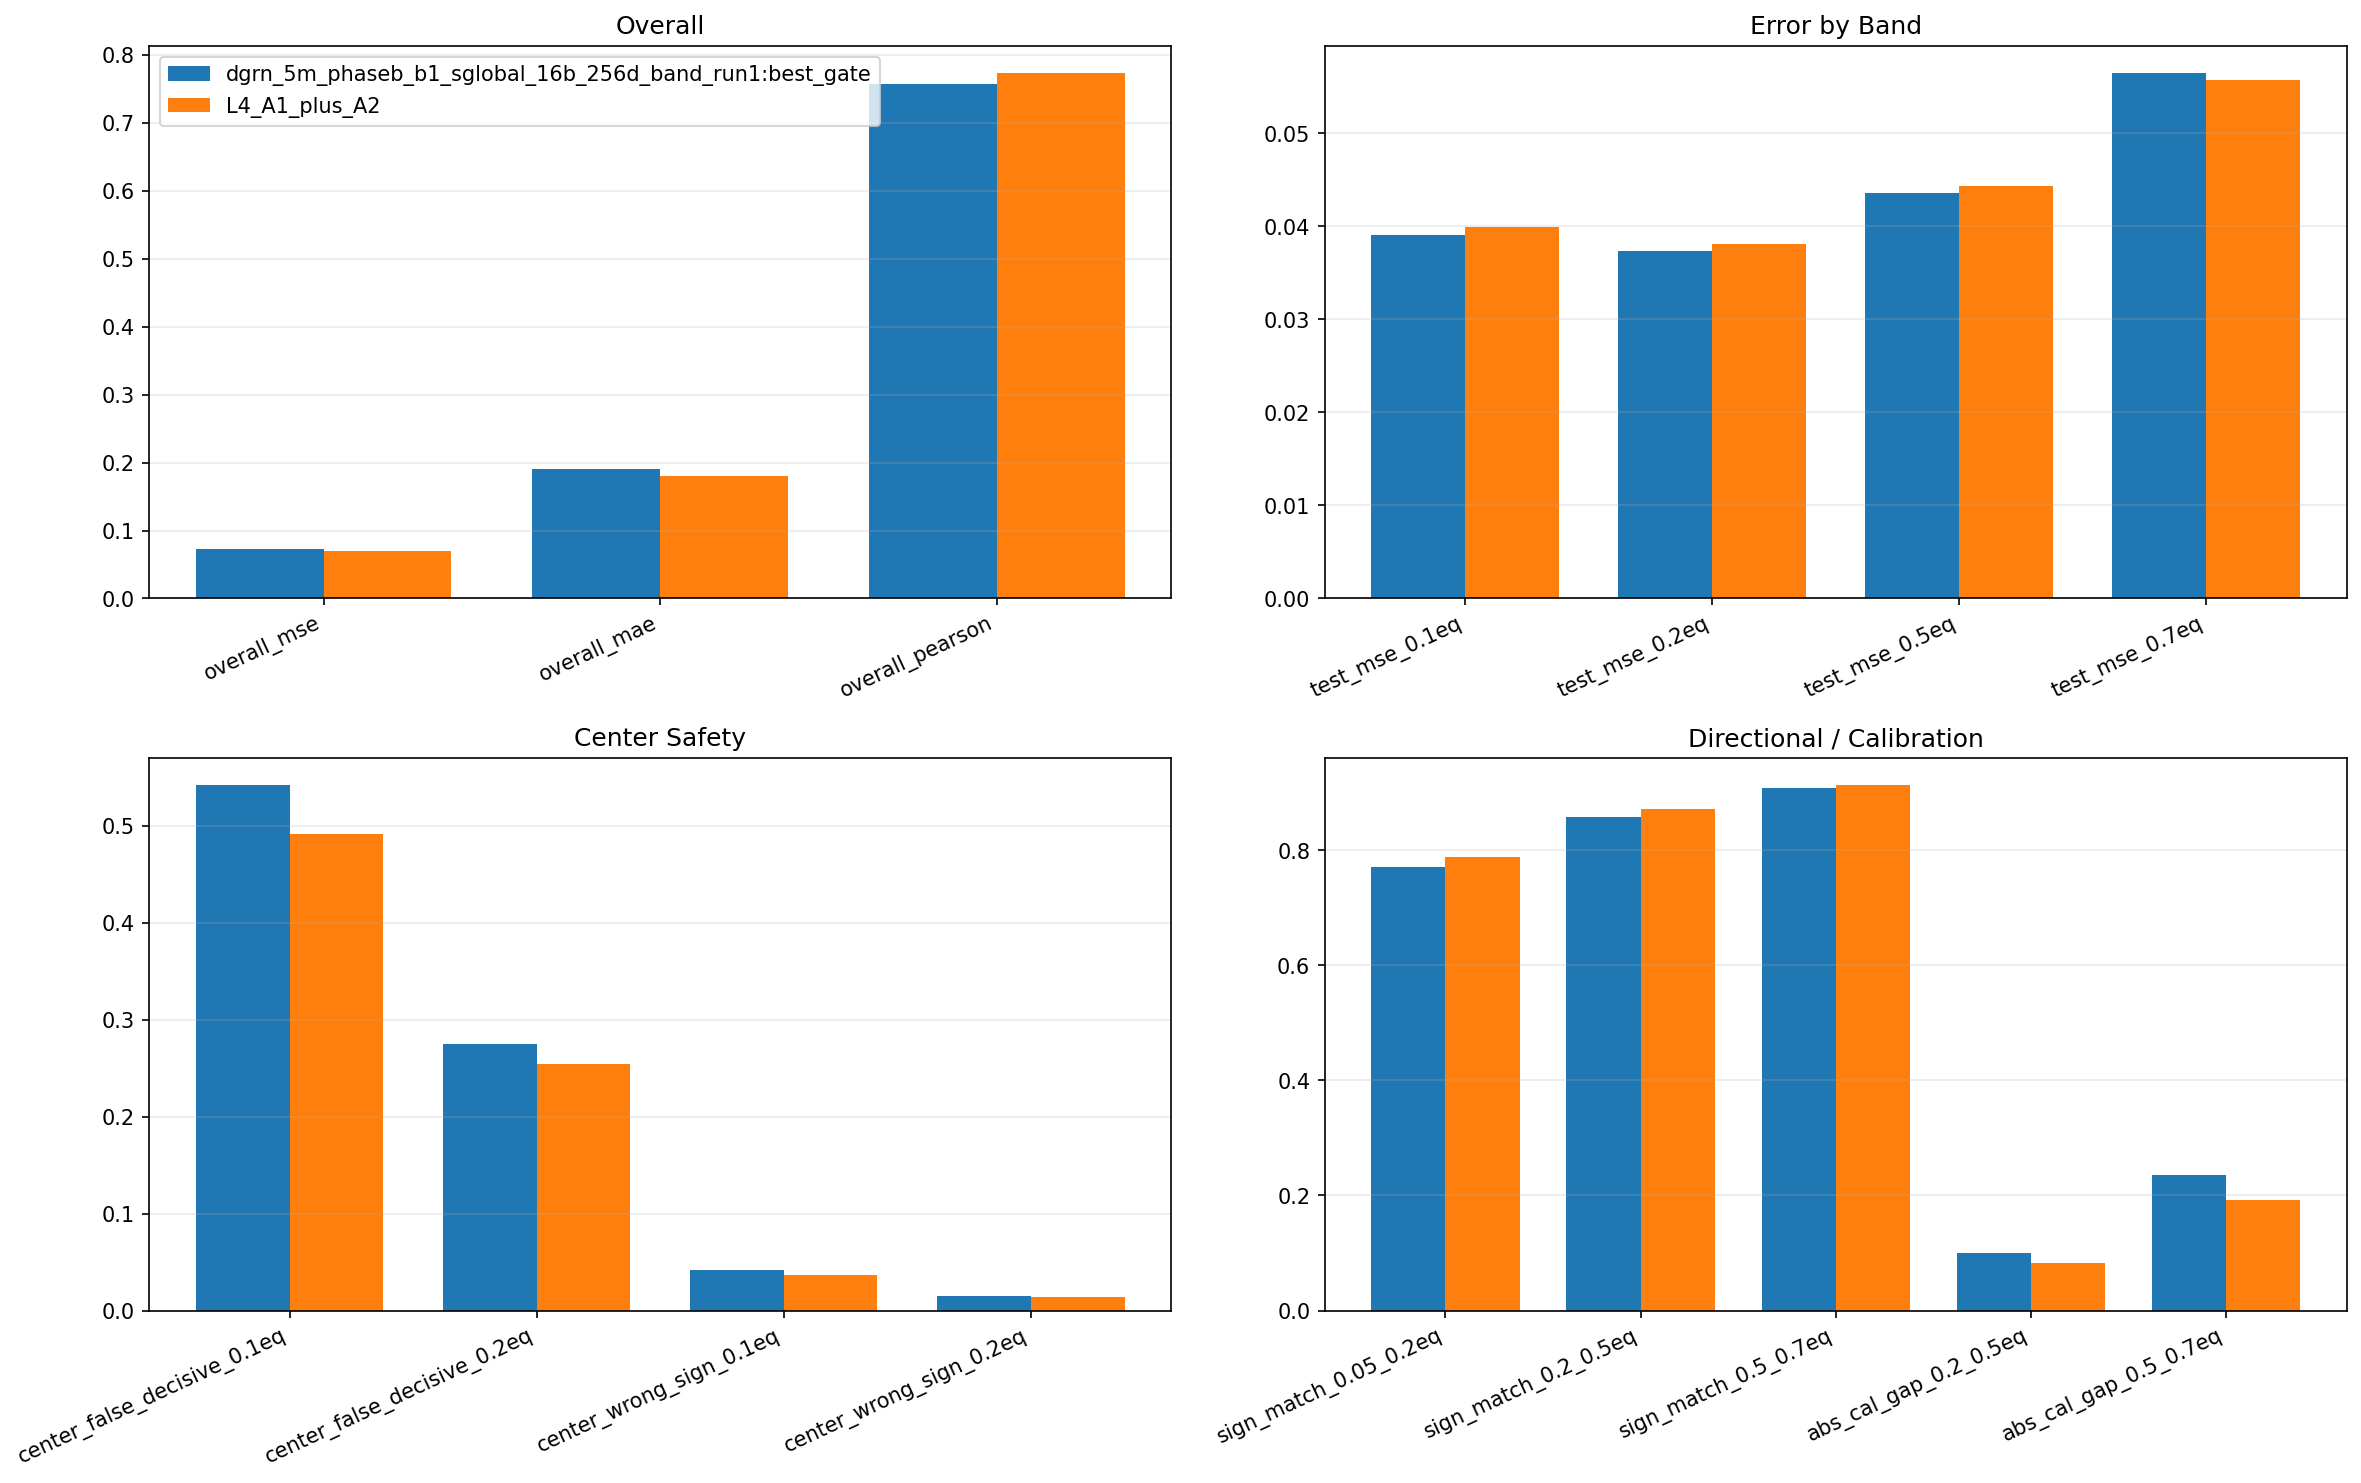

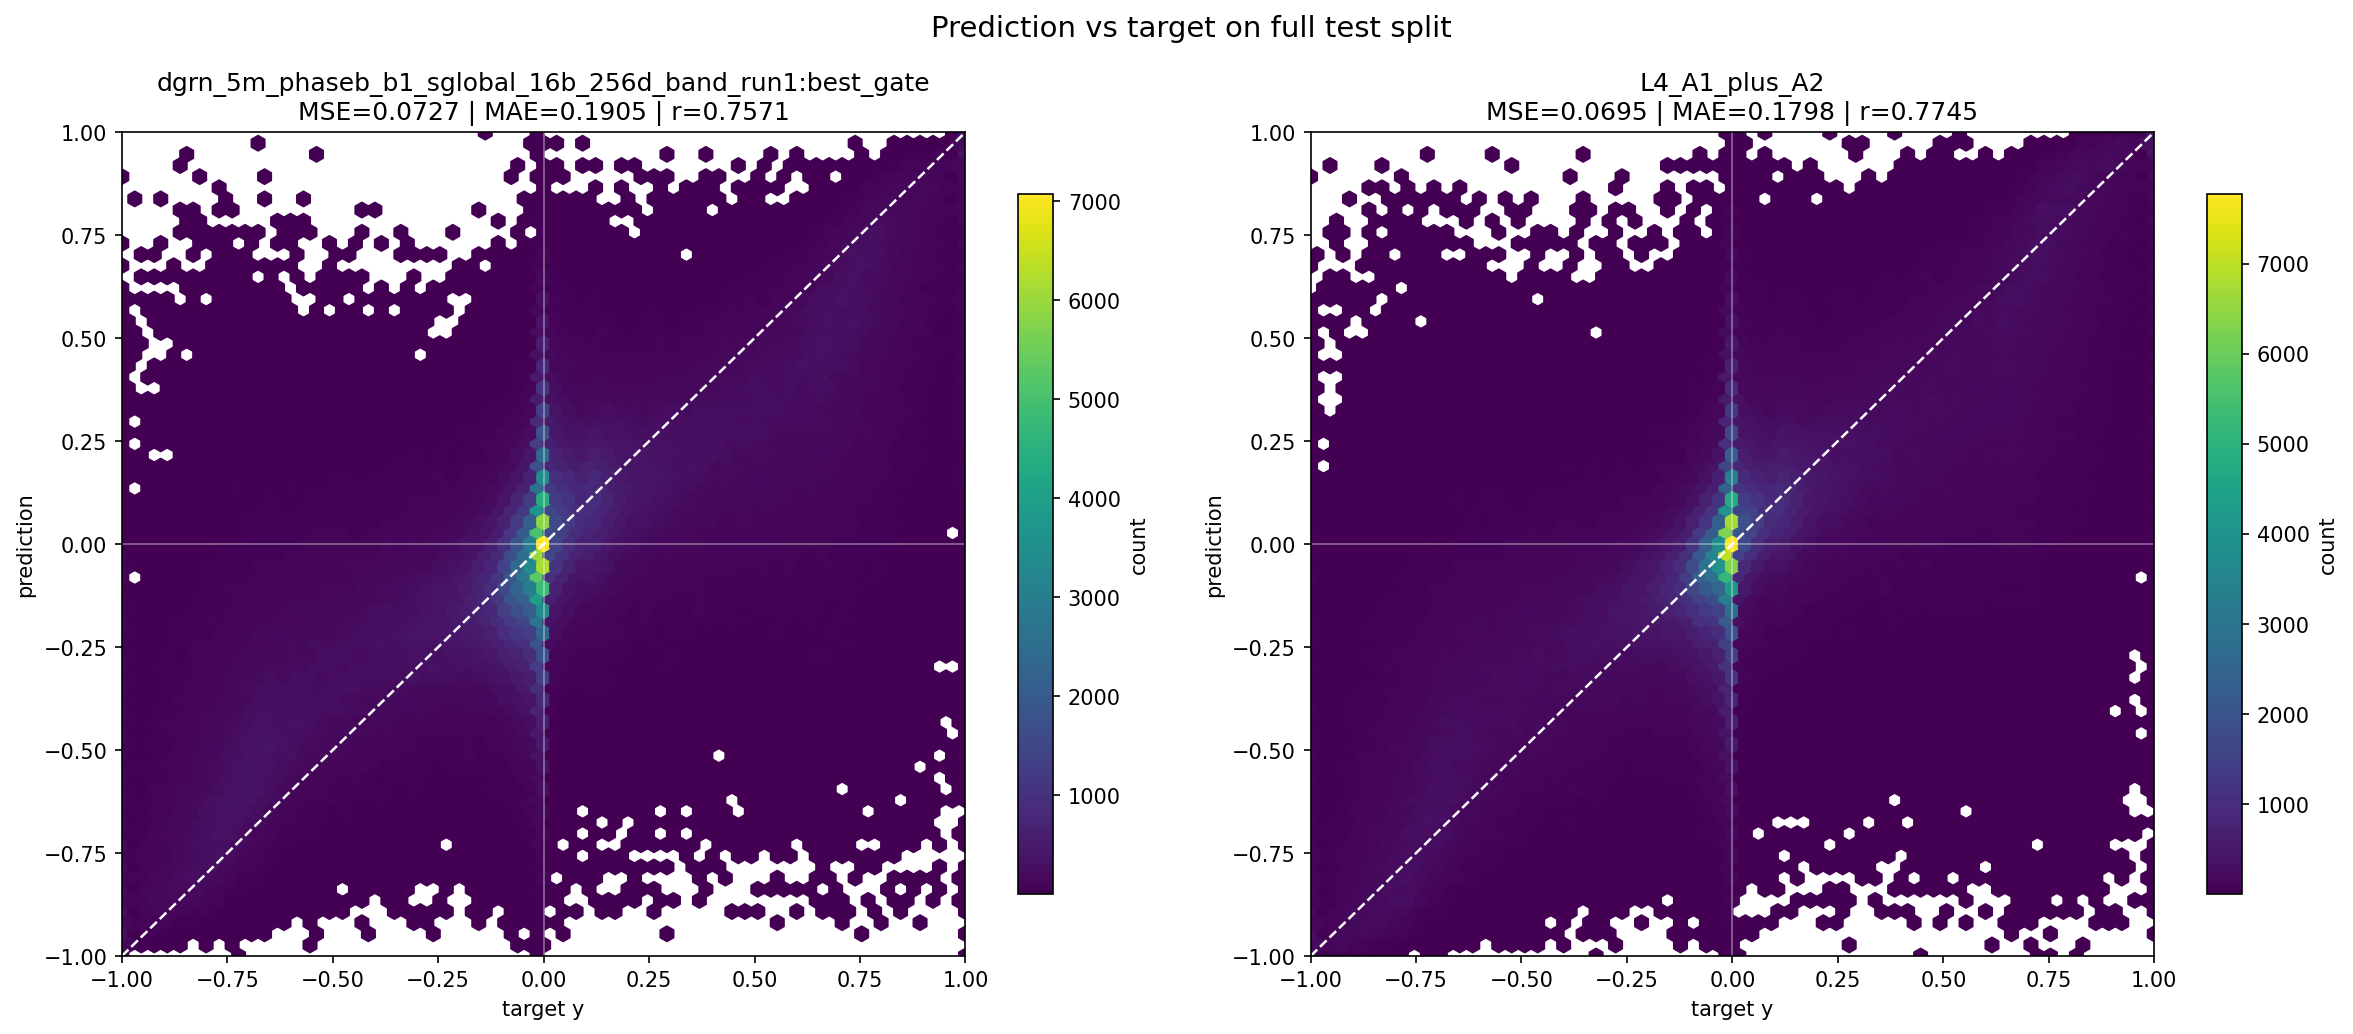

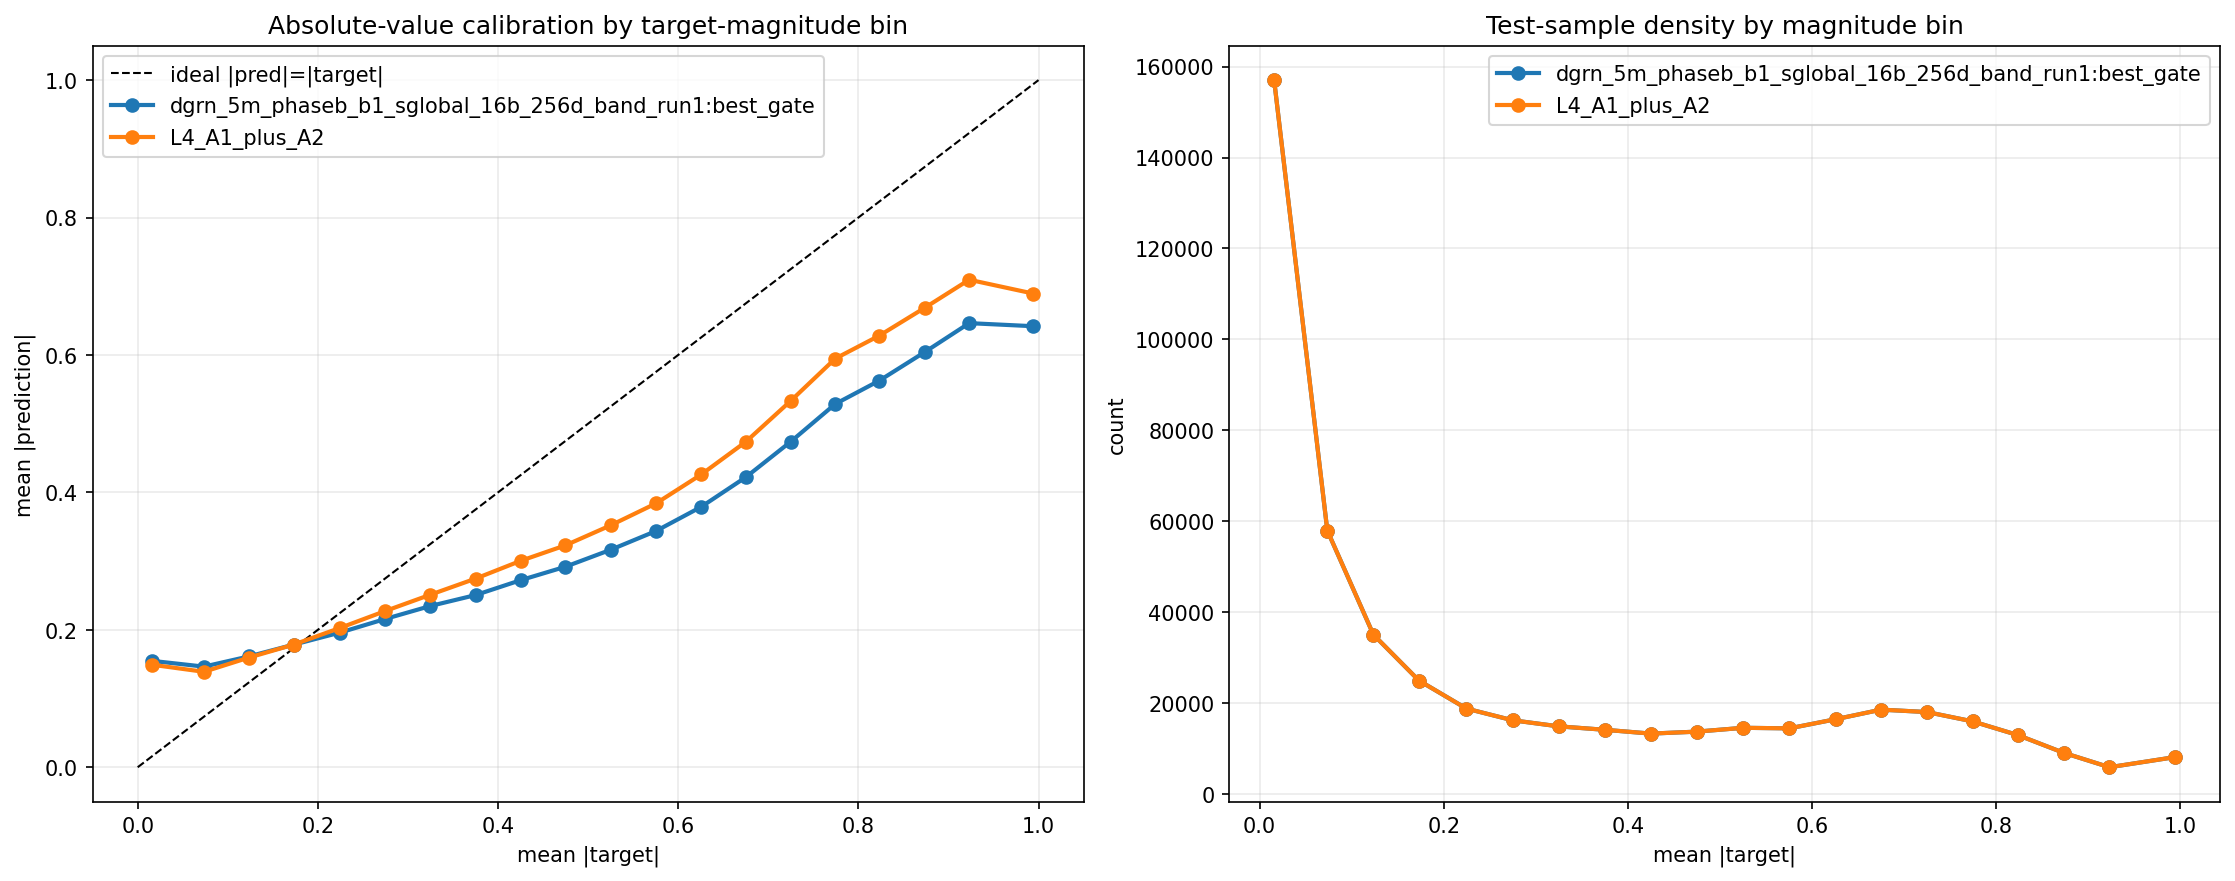

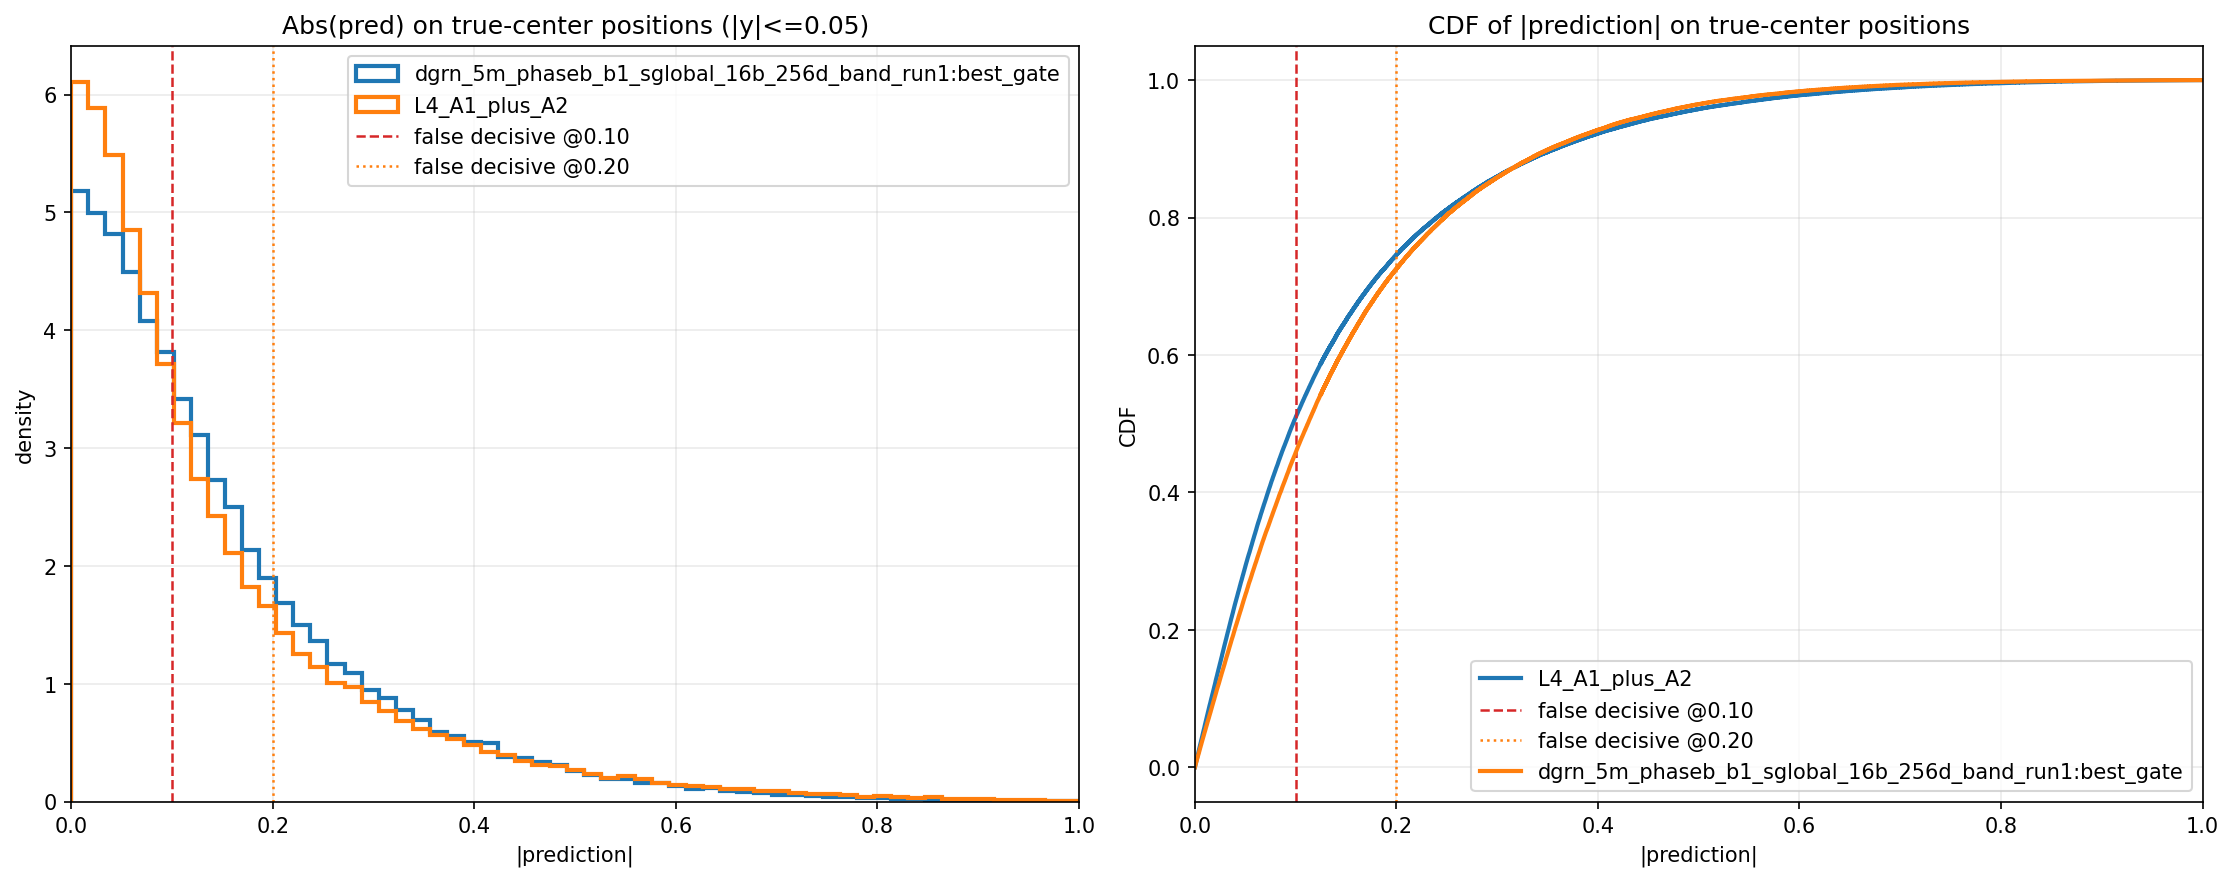

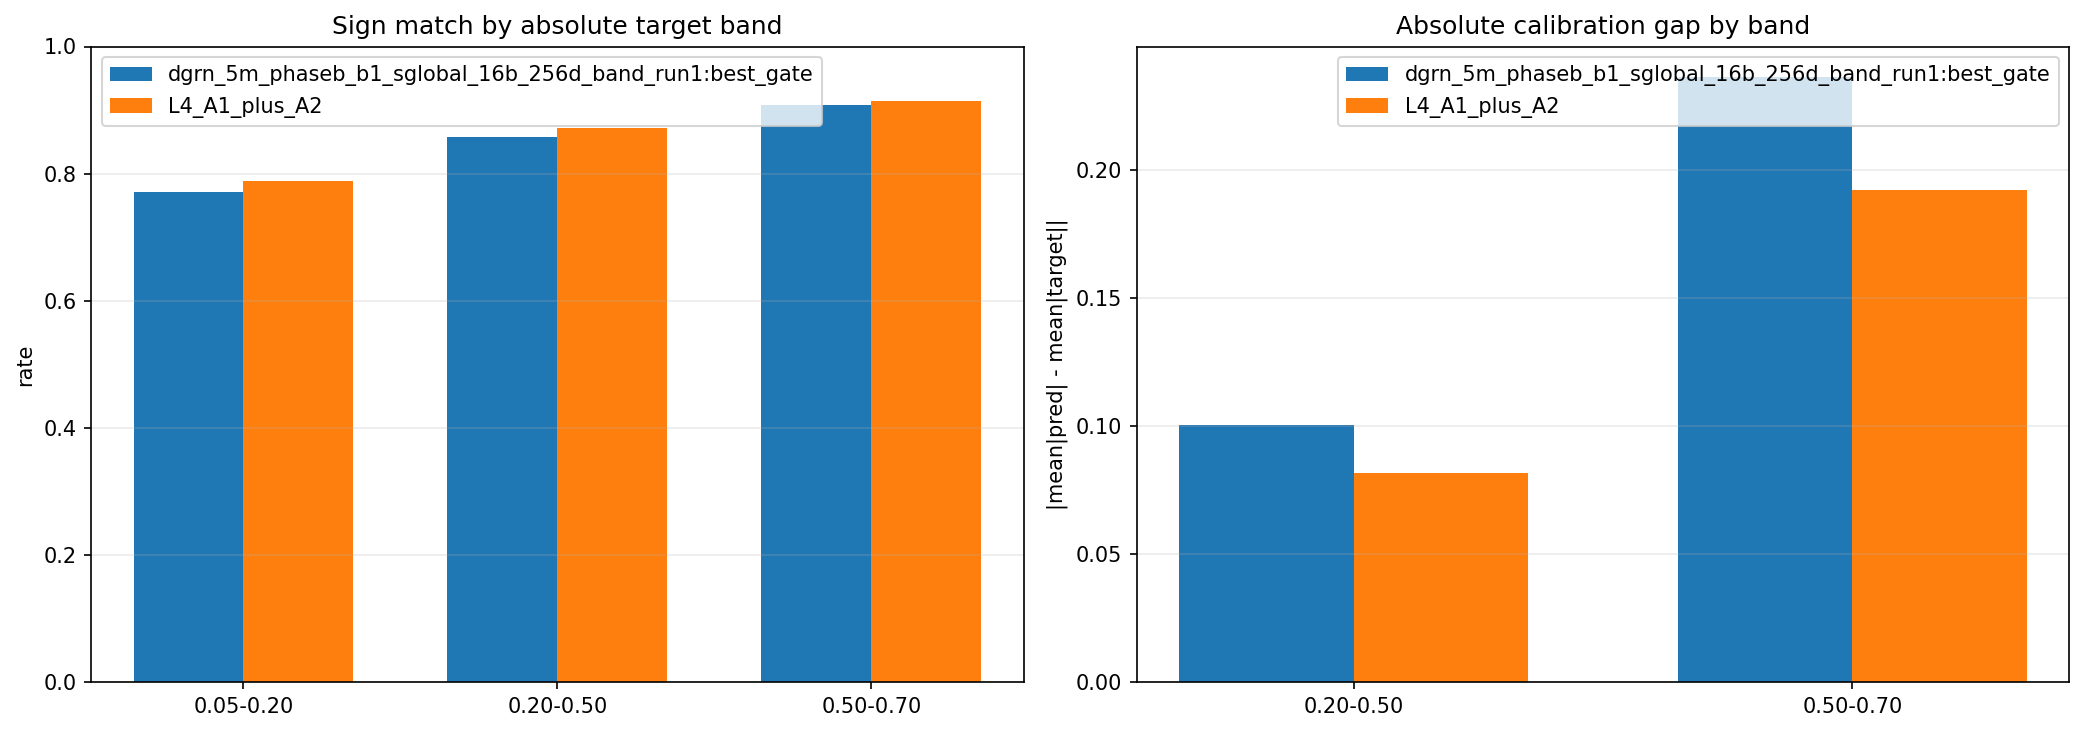

In [9]:
reports_dir = bench_paths['reports_dir']
plots_dir = bench_paths['plots_dir']

core_df = pd.read_csv(reports_dir / 'core_metrics_table.csv')
secondary_df = pd.read_csv(reports_dir / 'secondary_metrics_table.csv')
diagnostic_df = pd.read_csv(reports_dir / 'diagnostic_metrics_table.csv')
reliability_df = pd.read_csv(reports_dir / 'metric_reliability_catalog.csv')
calibration_df = pd.read_csv(reports_dir / 'absolute_calibration_curve.csv')
band_df = pd.read_csv(reports_dir / 'band_diagnostics.csv')
decision = json.loads((reports_dir / 'decision_summary.json').read_text(encoding='utf-8'))
runtime_check = json.loads((reports_dir / 'runtime_check.json').read_text(encoding='utf-8'))
benchmark_config = json.loads((reports_dir / 'benchmark_config.json').read_text(encoding='utf-8'))
sample_sizes = json.loads((reports_dir / 'sample_sizes.json').read_text(encoding='utf-8'))
candidate_eval = json.loads((reports_dir / 'candidate_eval_summary.json').read_text(encoding='utf-8'))
reference_eval_path = reports_dir / 'reference_eval_summary.json'
reference_eval = json.loads(reference_eval_path.read_text(encoding='utf-8')) if reference_eval_path.exists() else None
bootstrap_path = reports_dir / 'oracle_bootstrap_compare.csv'
bootstrap_df = pd.read_csv(bootstrap_path) if bootstrap_path.exists() else None

print('Decision summary:')
print(json.dumps(decision, indent=2, ensure_ascii=False))
print('Runtime check:')
print(json.dumps(runtime_check, indent=2, ensure_ascii=False))
print('Resolved benchmark config:')
print(json.dumps(benchmark_config, indent=2, ensure_ascii=False))
print('Sample sizes:')
print(json.dumps(sample_sizes, indent=2, ensure_ascii=False))

display(core_df)
display(secondary_df)
display(diagnostic_df)
display(reliability_df)
display(calibration_df.head(12))
display(band_df)
if bootstrap_df is not None:
    display(bootstrap_df)

for plot_name in [
    'core_metrics.png',
    'prediction_vs_target_hexbin.png',
    'absolute_calibration.png',
    'center_behavior.png',
    'sign_match_by_band.png',
]:
    plot_path = plots_dir / plot_name
    if plot_path.exists():
        display(Image(filename=str(plot_path)))
